In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import impuls_simulator as impuls_simulator
import ifb_selectors as selector

In [7]:
def spike_interval_by_peak(data, threshold_factor=2):
    data = np.array(data)
    baseline = np.median(data)
    uplift = np.std(data)
    threshold = baseline + threshold_factor*uplift

    left,right = 0,0
    # 1. Znajdź największy peak powyżej thresholdu
    idx_peak = np.argmax(data)
    if data[idx_peak] < threshold:
        return left, right, threshold  # brak impulsu

    # 2. Rozszerz w lewo
    left = idx_peak
    while left > 0 and data[left] > threshold:
        left -= 1
    # 3. Rozszerz w prawo
    right = idx_peak
    while right < len(data)-1 and data[right] > threshold:
        right += 1

    return left, right, threshold

def bandpass_filter(signal, fs, f_low, f_high):
    # Wykonanie FFT
    fft_signal = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    
    # Tworzenie maski dla wybranego pasma
    mask = (abs(freqs) >= f_low) & (abs(freqs) <= f_high)
    
    # Aplikacja maski (wyzerowanie składowych poza wybranym pasmem)
    fft_signal_filtered = fft_signal.copy()
    fft_signal_filtered[~mask] = 0
    
    # Odwrotna transformata Fouriera
    filtered_signal = np.real(np.fft.ifft(fft_signal_filtered))
    
    return filtered_signal, freqs, fft_signal, fft_signal_filtered

def impuls_detection(filtered,impuls_threshold):
    filtered_energy  = np.sum(filtered**2)
    impulses = (filtered > np.mean(filtered) + impuls_threshold*np.std(filtered)) | (filtered < np.mean(filtered) - impuls_threshold*np.std(filtered))

    filtered_no_impulses = filtered.copy()
    filtered_no_impulses[impulses] = 0
    filtered_no_impulses_energy = np.sum(filtered_no_impulses**2)
    return filtered_no_impulses_energy/filtered_energy

def calculate_analysis(signal, selektor, filter_threshold=1, impuls_threshold=1):
    #spektrogram
    fs = 1
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)
    
    #selektor
    results = selektor(Zxx)
    
    #odnalezienie granic
    left, right, threshold = spike_interval_by_peak(results,filter_threshold)

    #filtracja na podstawie otrzymanych granic
    filtered, _, _, _ = bandpass_filter(signal, fs, array_freq[left], array_freq[right])
    sigma = np.std(filtered)
    mu = np.mean(filtered)
    upper_threshold_filtered = mu + impuls_threshold*sigma
    lower_threshold_filtered = mu - impuls_threshold*sigma

    filtered_energy  = np.sum(filtered**2)
    impulses = (filtered > upper_threshold_filtered) | (filtered < lower_threshold_filtered)

    filtered_no_impulses = filtered.copy()
    filtered_no_impulses[impulses] = 0
    filtered_no_impulses_energy = np.sum(filtered_no_impulses**2)

    return filtered_no_impulses_energy/filtered_energy

def draw_analysis(signal, selektor, filter_threshold=1, impuls_threshold=1):
    #sygnał w czasie
    plt.figure(figsize=(10, 4))
    plt.plot(signal, linewidth=1)
    plt.title(f"Sygnał w czasie")
    plt.xlabel("Próbka")
    plt.ylabel("Amplituda")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    #spektrogram
    fs = 1
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)
    plt.figure(figsize=(18, 6))
    plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Czas [s]')
    plt.title('Spektrogram')
    plt.colorbar(label='Amplituda [dB]')
    plt.show()

    #selektor
    results = selektor(Zxx)
    #wyrysowanie wykresów
    plt.figure(figsize=(18,5))
    plt.plot(array_freq,results)
    plt.title("Wyniki selektora")
    plt.xlabel("Częstotliwość")
    plt.ylabel("Wartość selektora")
    plt.grid()

    left, right, threshold = spike_interval_by_peak(results,filter_threshold)

    filtered, _, _, _ = bandpass_filter(signal, fs, array_freq[left], array_freq[right])
    plt.figure(figsize=(18,5))
    plt.plot(filtered)
    plt.title("Sygnał po filtracji")
    plt.xlabel("Czas")
    plt.ylabel("Amplituda")
    plt.grid()



# Przygotowanie danych

### Pobranie danych z pliku

dict_keys(['__header__', '__version__', '__globals__', 'signal_early'])


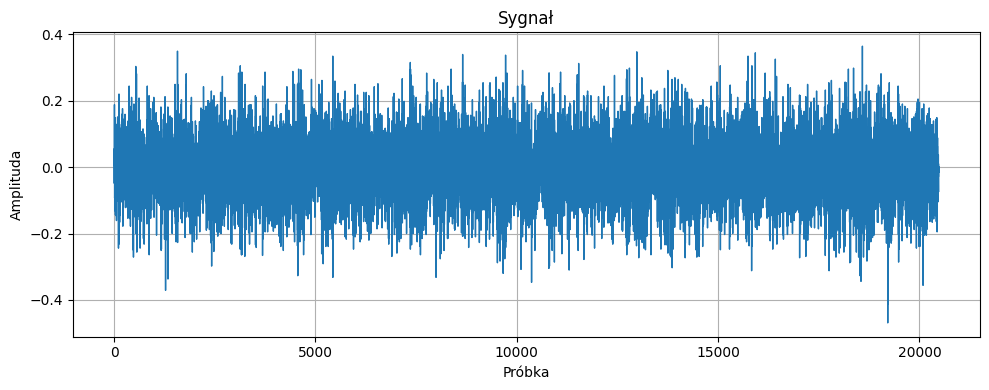

-0.002354736328125
0.08786925596907819


In [13]:
from scipy.io import loadmat

# wczytanie pliku
# data = loadmat('assets/vibration_dataset/Faulty/F1.mat')
# data = loadmat('assets/datasets/Healthy/H1.mat')
data = loadmat('assets/datasets/daniel/signal_early.mat')
signal = data["signal_early"][:,0]
# data = loadmat('assets/datasets/daniel/signal_medium_fault.mat')
# signal = data["signal_medium_fault"][:,0]
# data = loadmat('assets/datasets/daniel/signal_developed_fault.mat')
# signal = data["signal_developed_fault"][:,0]
keys = data.keys()
print(keys)
plt.figure(figsize=(10, 4))
plt.plot(signal, linewidth=1)
plt.title(f"Sygnał")
plt.xlabel("Próbka")
plt.ylabel("Amplituda")
plt.grid(True)
plt.tight_layout()
plt.show()
print(np.mean(signal))
print(np.std(signal))

### Wygenerowanie danych

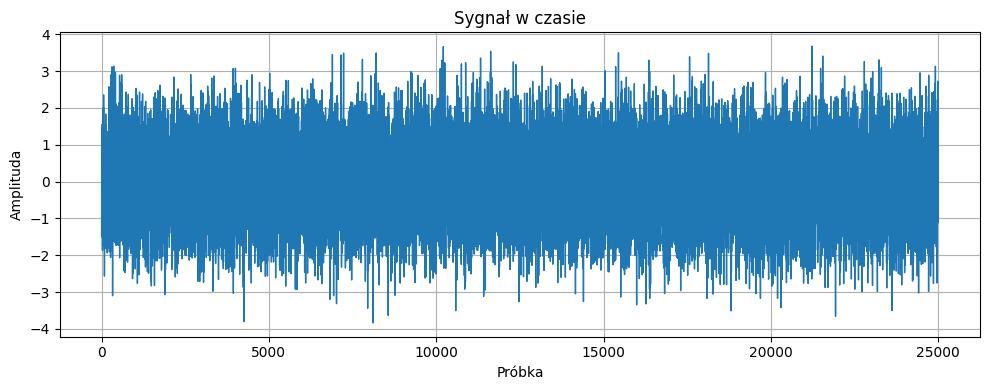

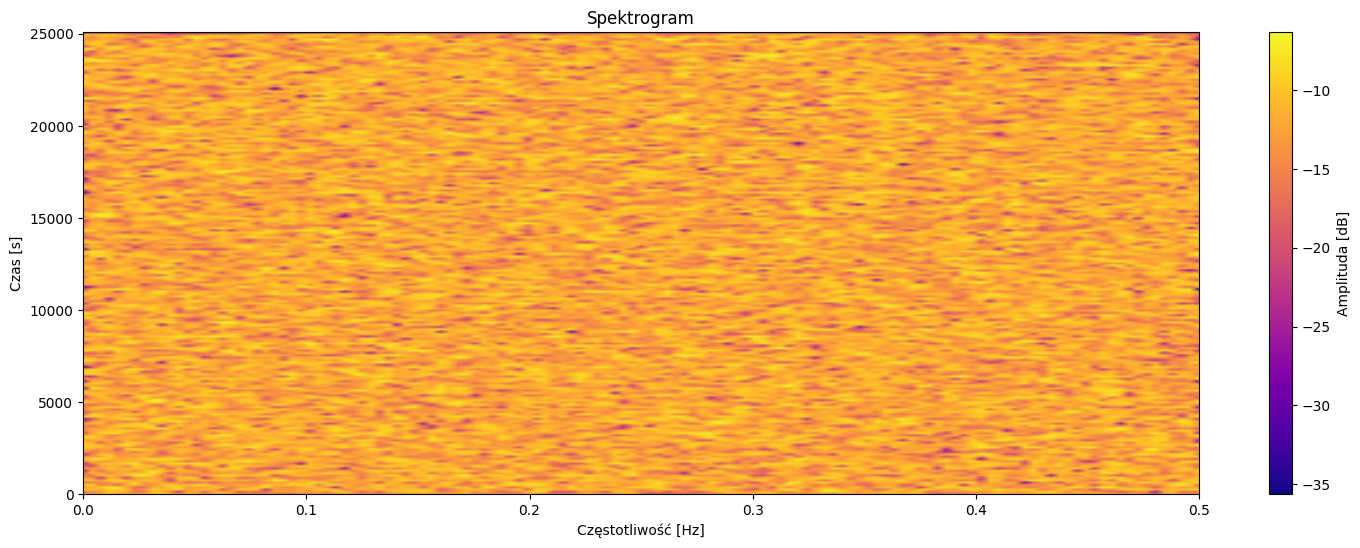

np.float64(1.0)

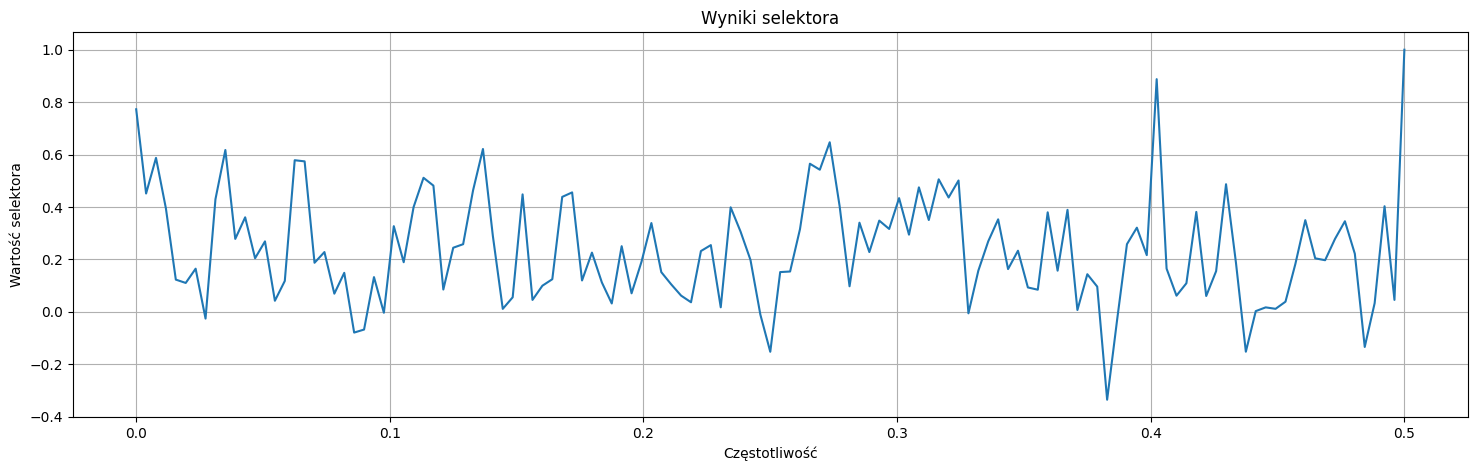

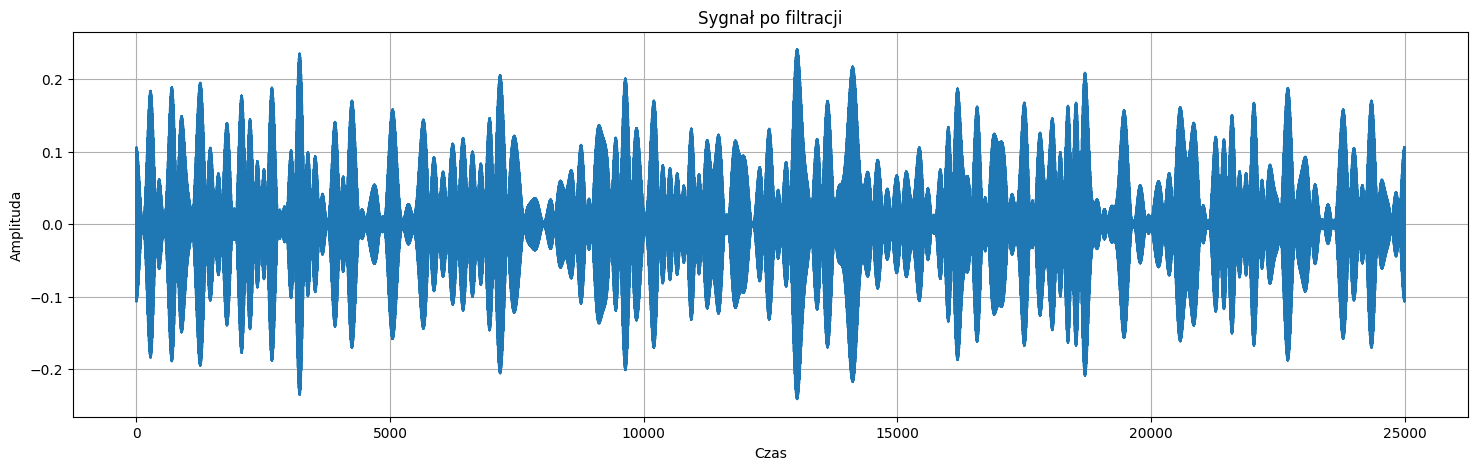

In [11]:
B=0
fs=25000
varsize=25000
fmod=13
f_center=2000
bandwidth=500
shift=0
sigma=1
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)
draw_analysis(signal,selector.SK)
calculate_analysis(signal,selector.SK,impuls_threshold=3)

## Spektrogram

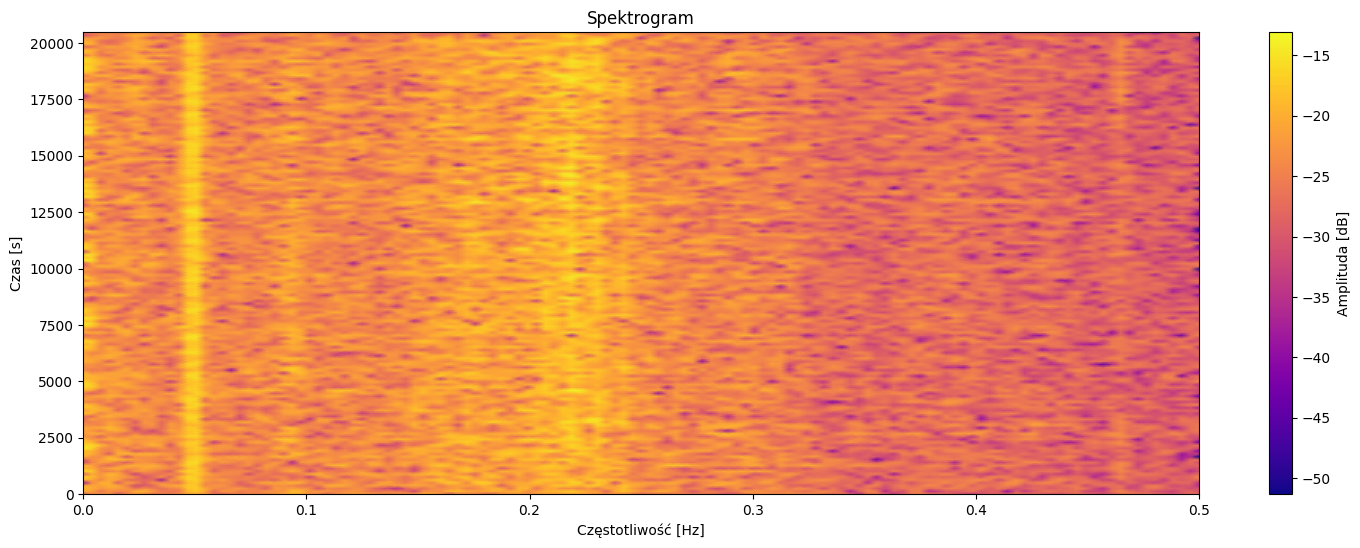

In [ ]:
    #obliczenie STFT
    fs = 1
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)
    #Wyrysowanie Wykresu
    plt.figure(figsize=(18, 6))
    plt.pcolormesh(array_freq, array_tt, 10*np.log10(Zxx.T), shading='gouraud', cmap='plasma')
    plt.xlabel('Częstotliwość [Hz]')
    plt.ylabel('Czas [s]')
    plt.title('Spektrogram')
    plt.colorbar(label='Amplituda [dB]')
    plt.show()

# Funkcje do analizy

# Selektory

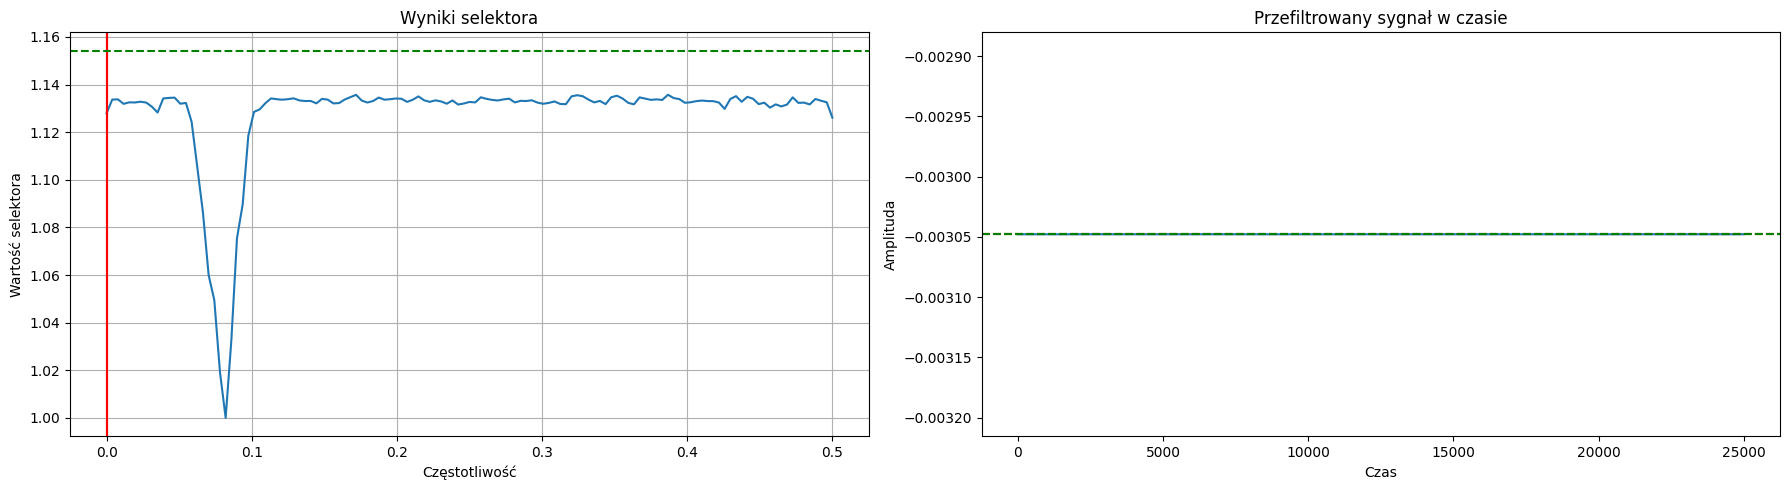

Dla selektora, średnia: 1.1275224475202905, odchylenie: 0.021189894913673256
Dla filtracji, średnia: -0.003047773908782995, odchylenie: 4.336808689942018e-19
1.0


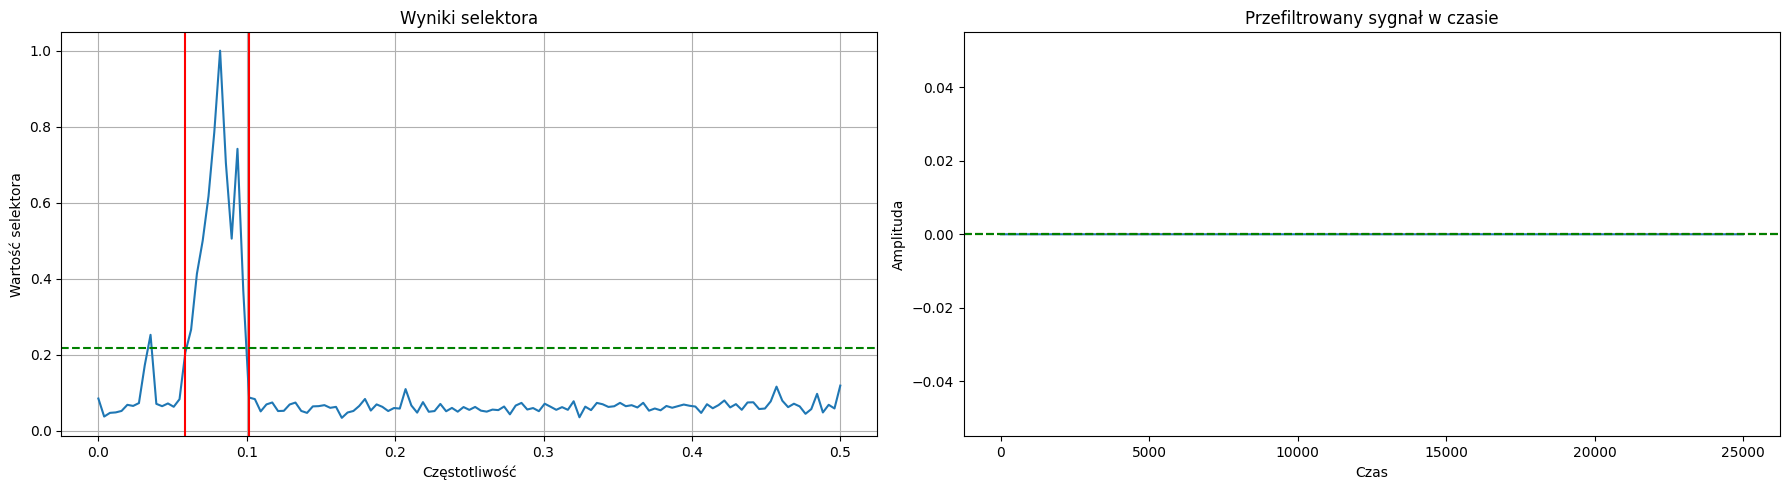

Dla selektora, średnia: 0.10838914011926815, odchylenie: 0.15377323758065028
Dla filtracji, średnia: 0.0, odchylenie: 0.0
nan


C:\Users\marek\AppData\Local\Temp\ipykernel_6388\2583743314.py:44: RuntimeWarning: invalid value encountered in scalar divide
  return filtered_no_impulses_energy/filtered_energy


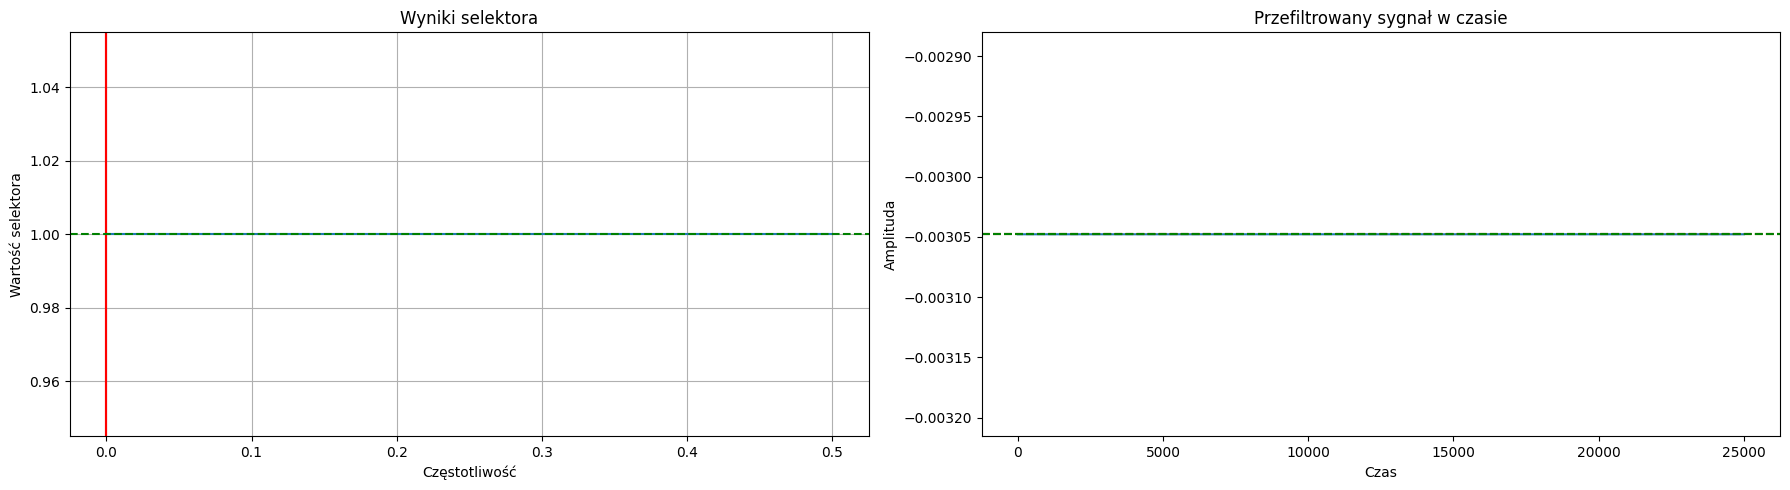

Dla selektora, średnia: 1.0, odchylenie: 0.0
Dla filtracji, średnia: -0.003047773908782995, odchylenie: 4.336808689942018e-19
1.0


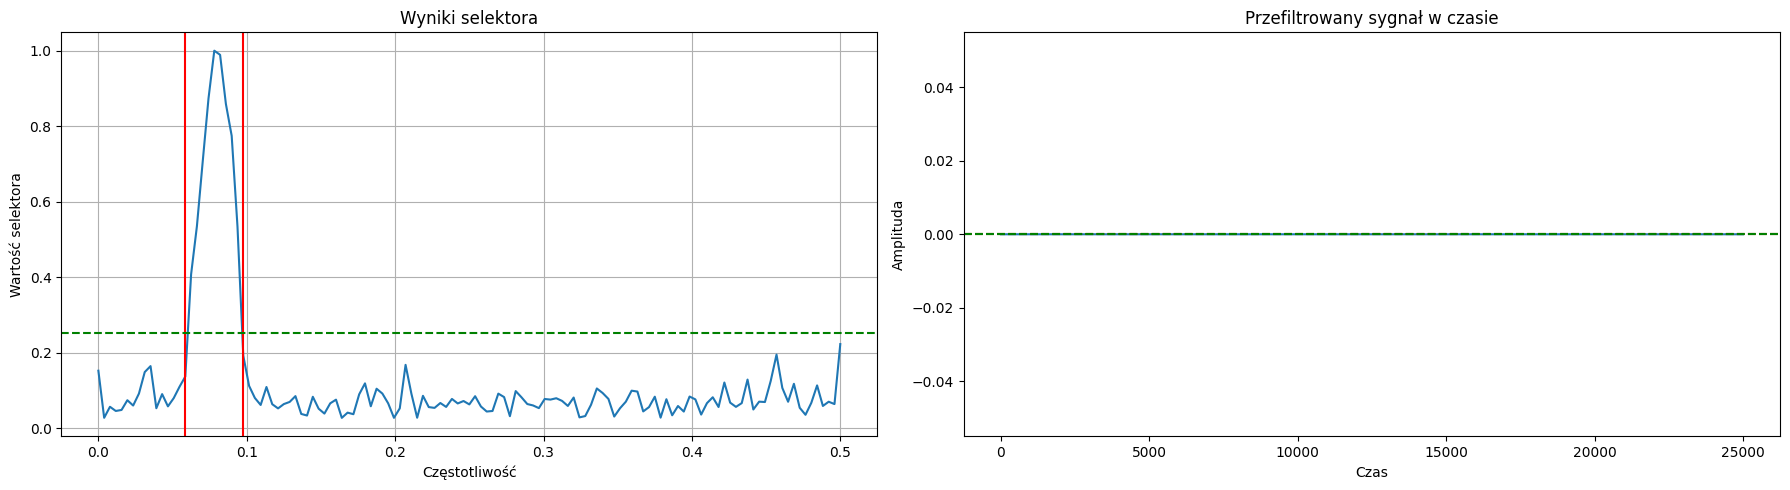

Dla selektora, średnia: 0.12193439978768493, odchylenie: 0.1811376165848997
Dla filtracji, średnia: 0.0, odchylenie: 0.0
nan


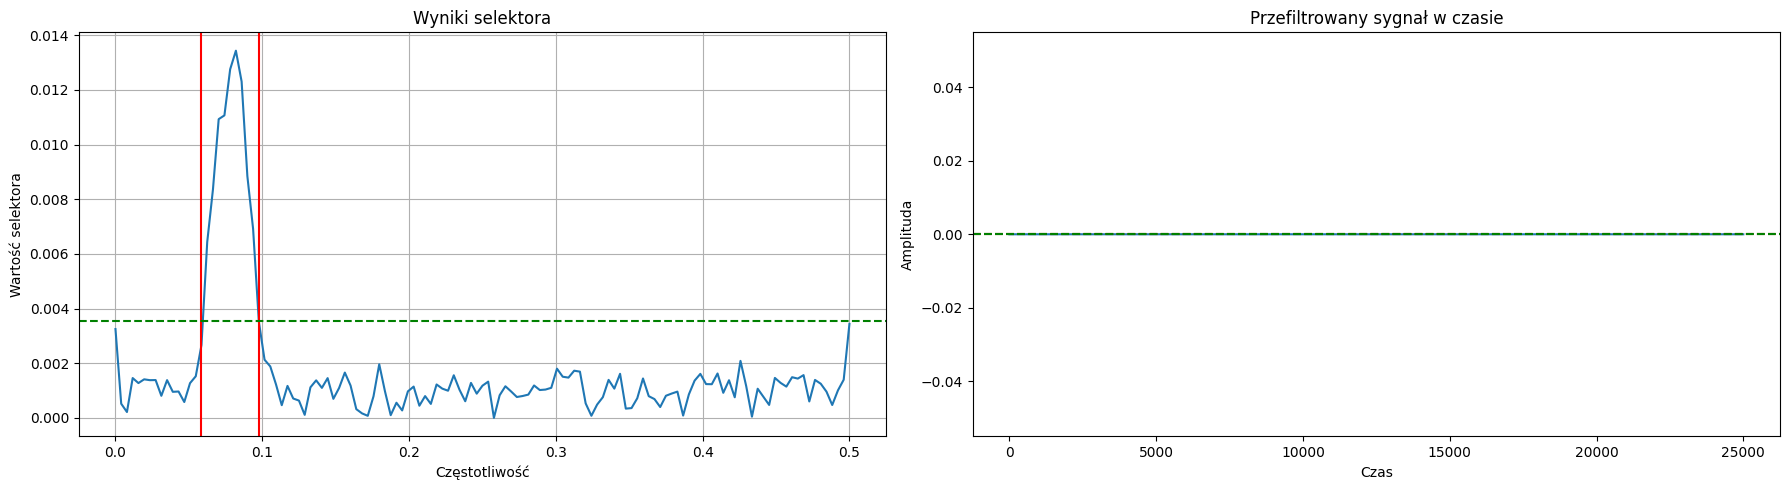

Dla selektora, średnia: 0.0017095343879307426, odchylenie: 0.0024620384677492713
Dla filtracji, średnia: 0.0, odchylenie: 0.0
nan


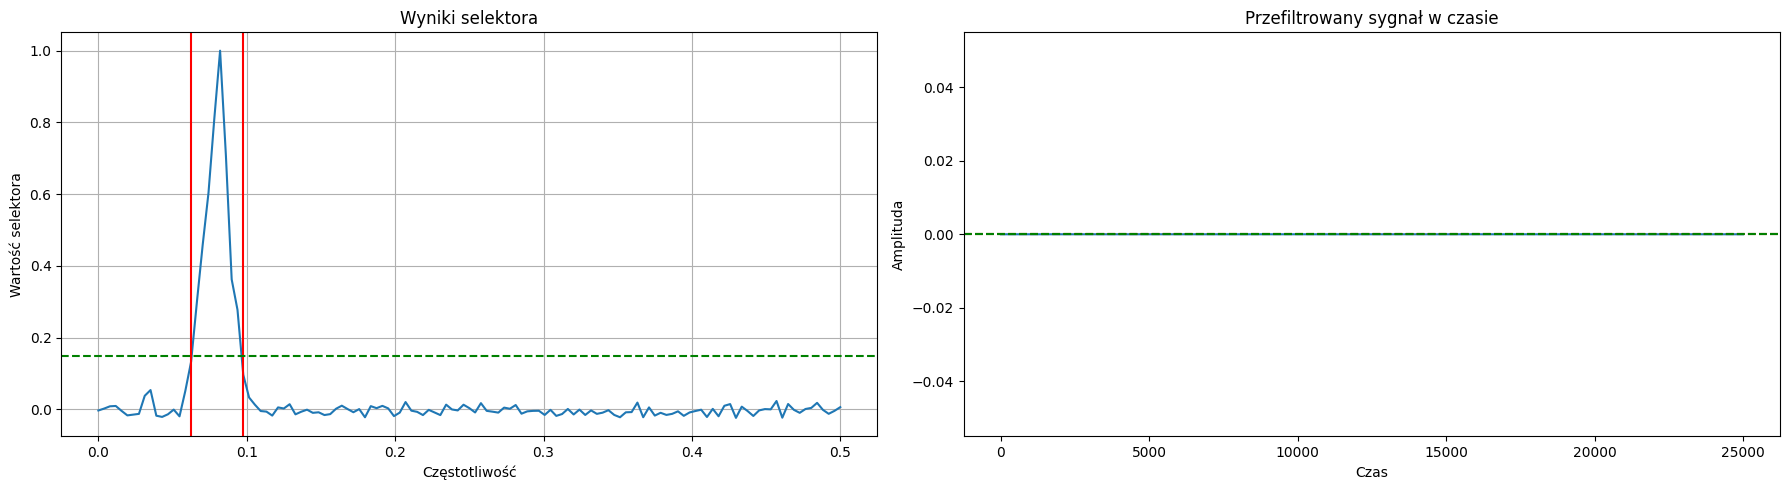

Dla selektora, średnia: 0.03429796907714742, odchylenie: 0.15072218262293394
Dla filtracji, średnia: 0.0, odchylenie: 0.0
nan


In [23]:
import ifb_selectors as selector
filter_threshold = 1
impuls_threshold = 1
sk_results = selector.SK(Zxx)
print(selector_analysis(sk_results,filter_threshold,impuls_threshold))
jb_results = selector.JB(Zxx)
print(selector_analysis(jb_results,filter_threshold,impuls_threshold))
kss_results = selector.KSS(Zxx)
print(selector_analysis(kss_results,filter_threshold,impuls_threshold))
ad_results = selector.AD(Zxx)
print(selector_analysis(ad_results,filter_threshold,impuls_threshold))
cvm_results = 1-selector.CVM(Zxx)
print(selector_analysis(cvm_results,filter_threshold,impuls_threshold))
cvs_results = selector.CVS(Zxx)
print(selector_analysis(cvs_results,filter_threshold,impuls_threshold))

# Analiza bez wykresów

In [19]:
import impuls_simulator as impuls_simulator
B=10
fs=25000
varsize=25000
fmod=30
f_center=2000
bandwidth=500
shift=0
sigma = 3
signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)


def full_signal_analysis(selector,filter_threshold,impuls_threshold,B=10,fs=25000,varsize=25000,fmod=30,f_center=2000,bandwidth=500,shift=0,sigma = 3):
    signal = impuls_simulator.gen_signal(B,fs,varsize,fmod,f_center,bandwidth,shift,sigma)
    fs = 1
    array_freq, array_tt, matrix_Zxx = scipy.signal.stft(signal, fs = fs, window = 'hann')
    Zxx = np.abs(matrix_Zxx)

    results = selector(Zxx)
    left, right, threshold = spike_interval_by_peak(results,filter_threshold)

    #filtracja na podstawie otrzymanych granic
    filtered, _, _, _ = bandpass_filter(signal, fs, array_freq[left], array_freq[right])
    sigma = np.std(filtered)
    mu = np.mean(filtered)
    upper_threshold_filtered = mu + impuls_threshold*sigma
    lower_threshold_filtered = mu - impuls_threshold*sigma


    filtered_energy  = np.sum(filtered**2)
    impulses = (filtered > np.mean(filtered) + impuls_threshold*np.std(filtered)) | (filtered < np.mean(filtered) - impuls_threshold*np.std(filtered))

    filtered_no_impulses = filtered.copy()
    filtered_no_impulses[impulses] = 0
    filtered_no_impulses_energy = np.sum(filtered_no_impulses**2)
    # print(f"Dla selektora, średnia: {np.mean(results)}, odchylenie: {np.std(results)}")
    # print(f"Dla filtracji, średnia: {np.mean(filtered)}, odchylenie: {np.std(filtered)}")

    return filtered_no_impulses_energy/filtered_energy

In [20]:
import ifb_selectors as selector
filter_threshold = 1/2
impuls_threshold = 1
full_signal_analysis(selector.SK,filter_threshold,impuls_threshold,B=0)

np.float64(0.2058048582809972)

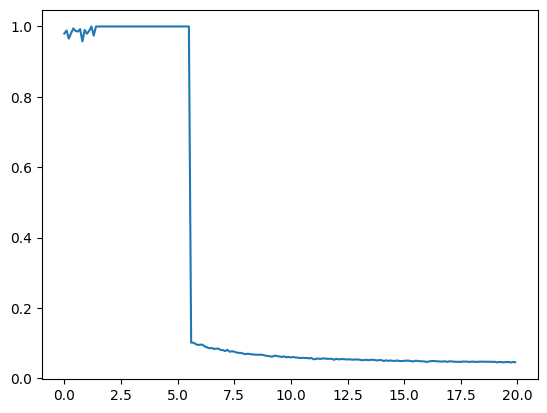

In [24]:
impuls_amps = np.arange(0,20,0.1)
results = np.zeros(len(impuls_amps))

filter_threshold = 1/2
impuls_threshold = 3



for i in range(len(impuls_amps)):
    results[i] = full_signal_analysis(selector.SK,filter_threshold,impuls_threshold,B=impuls_amps[i],fmod=13,sigma=0.1)

plt.plot(impuls_amps,results)